# Math to GPU

In [ ]:
from numba import config
config.CUDA_ENABLE_PYNVJITLINK = 1

## C = A + B

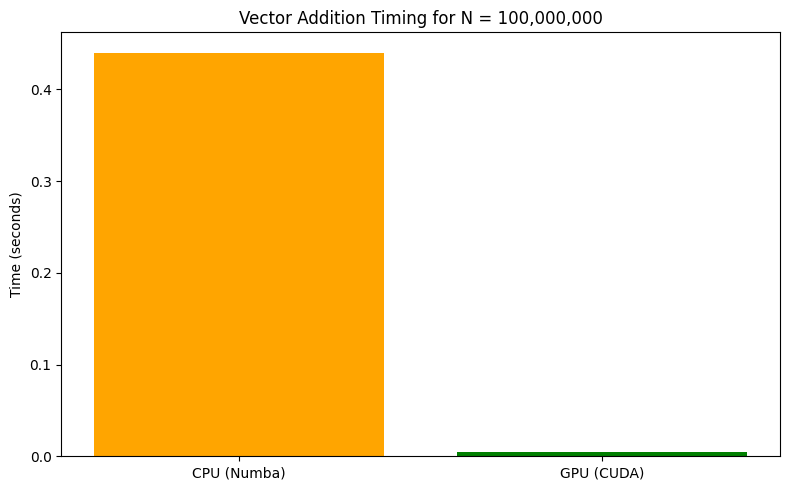

In [ ]:
import numpy as np
import time
from numba import cuda, njit
import matplotlib.pyplot as plt

# Problem size
N = 100_000_000

# Host arrays
a = np.ones(N, dtype=np.float32)
b = np.ones(N, dtype=np.float32)
c_cpu = np.zeros(N, dtype=np.float32)
c_gpu = np.zeros(N, dtype=np.float32)

# --------------------------------
@njit
def vector_add_cpu(a, b, out):
    for i in range(a.size):
        out[i] = a[i] + b[i]

# --------------------------------
@cuda.jit
def vector_add_gpu(a, b, out):
    i = cuda.grid(1)
    if i < a.size:
        out[i] = a[i] + b[i]

# CPU timing
start_cpu = time.time()
vector_add_cpu(a, b, c_cpu)
end_cpu = time.time()
cpu_time = end_cpu - start_cpu

# GPU setup
d_a = cuda.to_device(a)
d_b = cuda.to_device(b)
d_c = cuda.device_array_like(a)

threads_per_block = 256
blocks_per_grid = (a.size + threads_per_block - 1) // threads_per_block

# Warm-up run
vector_add_gpu[blocks_per_grid, threads_per_block](d_a, d_b, d_c)
cuda.synchronize()

# GPU timing
start_gpu = time.time()
vector_add_gpu[blocks_per_grid, threads_per_block](d_a, d_b, d_c)
cuda.synchronize()
end_gpu = time.time()
gpu_time = end_gpu - start_gpu

# Copy result back
d_c.copy_to_host(c_gpu)

# Verify
assert np.allclose(c_cpu, c_gpu)

# --------------------------------
# Plot
labels = ['CPU (Numba)', 'GPU (CUDA)']
times = [cpu_time, gpu_time]

plt.figure(figsize=(8, 5))
plt.bar(labels, times, color=['orange', 'green'])
plt.title(f"Vector Addition Timing for N = {N:,}")
plt.ylabel("Time (seconds)")
plt.tight_layout()
plt.show()

## Monte Carlo Estimation of π (Pi)


1. **Generate** $N$ random points $(x, y)$ where $-1 \le x \le 1$ and $-1 \le y \le 1$ (within a square of side 2 centered at origin).

2. **Count** the number of points ($N_{inside}$) that satisfy $x^2 + y^2 \le 1$ (inside a unit circle).

3. **Estimate** $\pi$ using the formula:

   $$\pi \approx 4 \times \frac{N_{inside}}{N}$$

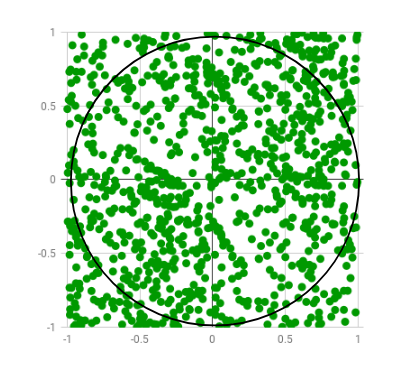

### Monte carlo Methods

Monte Carlo methods vary, but tend to follow a particular pattern:

1. Define a domain of possible inputs.
2. Generate inputs randomly from a probability distribution over the domain.
3. Perform a deterministic computation of the outputs.
4. Aggregate the results.

![image.png](
...)

In [ ]:
import random
import numpy as np
from numba import jit
import time
import matplotlib.pyplot as plt

@njit
def estimate_pi_numba(n_points):
    inside_circle = 0
    for _ in range(n_points):
        x = random.random()
        y = random.random()
        if x**2 + y**2 <= 1:
            inside_circle += 1
    return 4 * inside_circle / n_points

def estimate_pi_python(n_points):
    inside_circle = 0
    for _ in range(n_points):
        x = random.random()
        y = random.random()
        if x**2 + y**2 <= 1:
            inside_circle += 1
    return 4 * inside_circle / n_points

n_points = 1000000

start_time = time.time()
pi_python = estimate_pi_python(n_points)
end_time = time.time()
print(f"Pi (Python): {pi_python:.6f}, Time: {end_time - start_time:.4f} seconds")

start_time = time.time()
pi_numba = estimate_pi_numba(n_points)
end_time = time.time()
print(f"Pi (Numba): {pi_numba:.6f}, Time: {end_time - start_time:.4f} seconds")

Pi (Python): 3.144976, Time: 0.2997 seconds
Pi (Numba): 3.142236, Time: 0.1103 seconds


In [ ]:
@cuda.jit
def estimate_pi_cuda_kernel_simple(n_points, out):
    idx = cuda.grid(1)
    if idx < n_points:
        x = random.random()
        y = random.random()
        if x * x + y * y <= 1.0:
            out[idx] = 1
        else:
            out[idx] = 0

def estimate_pi_cuda_simple(n_points, threads_per_block=128):
    blocks_per_grid = (n_points + (threads_per_block - 1)) // threads_per_block
    results = cuda.device_array(n_points, dtype=np.int32)

    start_time = time.time()
    estimate_pi_cuda_kernel_simple[blocks_per_grid, threads_per_block](n_points, results)
    cuda.synchronize()
    end_time = time.time()

    inside_count = results.sum()
    pi_estimate = 4 * inside_count / n_points
    gpu_time = end_time - start_time
    return pi_estimate, gpu_time

## Cosine Simmilarity

Cosine similarity is a measure of similarity between two non-zero vectors of an inner product space. It quantifies the cosine of the angle between the vectors, thus indicating whether two vectors are pointing in roughly the same direction. It's often used to measure the similarity between documents, but it has various applications across different fields.

$$\text{Cosine Similarity}(A, B) = \frac{A \cdot B}{\|A\| \|B\|} = \frac{\sum_{i=1}^{n} A_i B_i}{\sqrt{\sum_{i=1}^{n} A_i^2} \sqrt{\sum_{i=1}^{n} B_i^2}}$$

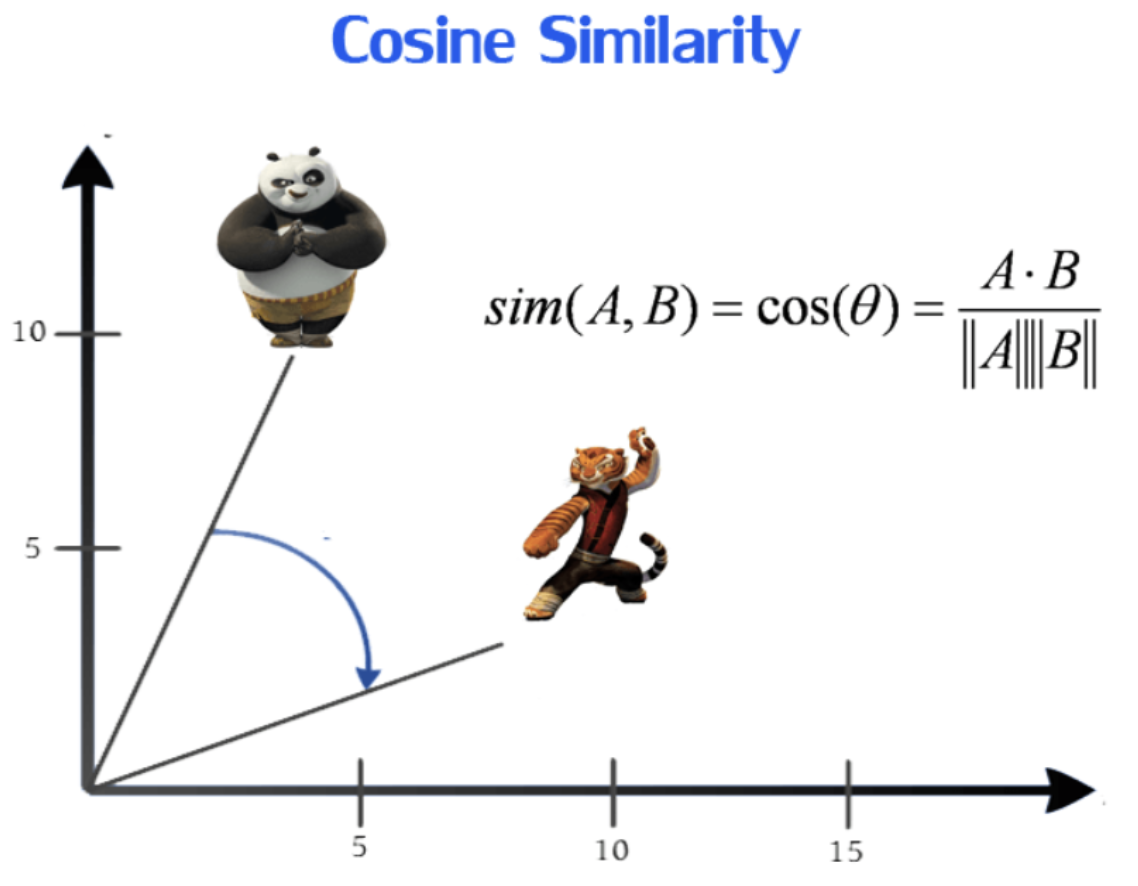

In [ ]:
from numba import config
import random
import time
from numba import jit, cuda
import numpy as np

# Sample data
vector_a = np.random.rand(1000)
vector_b = np.random.rand(1000)

# Cosine similarity without Numba
def cosine_similarity_no_numba(a, b):
    dot_product = np.dot(a, b)
    magnitude_a = np.linalg.norm(a)
    magnitude_b = np.linalg.norm(b)
    return dot_product / (magnitude_a * magnitude_b)

# Cosine similarity with Numba
@jit(nopython=True)
def cosine_similarity_numba(a, b):
    dot_product = np.dot(a, b)
    magnitude_a = np.linalg.norm(a)
    magnitude_b = np.linalg.norm(b)
    return dot_product / (magnitude_a * magnitude_b)


# Without Numba
start_time = time.time()
result_no_numba = cosine_similarity_no_numba(vector_a, vector_b)
end_time = time.time()
print(f"Cosine Similarity (without Numba): {result_no_numba}")
print(f"Execution Time (without Numba): {end_time - start_time:.6f} seconds")


# With Numba
start_time = time.time()
result_numba = cosine_similarity_numba(vector_a, vector_b)
end_time = time.time()
print(f"Cosine Similarity (with Numba): {result_numba}")
print(f"Execution Time (with Numba): {end_time - start_time:.6f} seconds")


Cosine Similarity (without Numba): 0.7370922493848446
Execution Time (without Numba): 0.000200 seconds
Cosine Similarity (with Numba): 0.7370922493848446
Execution Time (with Numba): 0.123078 seconds


In [ ]:
import numpy as np
from numba import jit, cuda
import time
import math

def cosine_similarity_python(vector_a, vector_b):
    """Calculates the cosine similarity between two vectors using NumPy."""
    dot_product = np.dot(vector_a, vector_b)
    norm_a = np.linalg.norm(vector_a)
    norm_b = np.linalg.norm(vector_b)
    if norm_a == 0 or norm_b == 0:
        return 0.0
    return dot_product / (norm_a * norm_b)

@jit(nopython=True)
def cosine_similarity_numba_cpu(vector_a, vector_b):
    """Calculates the cosine similarity between two vectors using Numba (CPU)."""
    dot_product = 0.0
    norm_a_sq = 0.0
    norm_b_sq = 0.0
    n = len(vector_a)
    for i in range(n):
        dot_product += vector_a[i] * vector_b[i]
        norm_a_sq += vector_a[i] * vector_a[i]
        norm_b_sq += vector_b[i] * vector_b[i]
    norm_a = np.sqrt(norm_a_sq)
    norm_b = np.sqrt(norm_b_sq)
    if norm_a == 0.0 or norm_b == 0.0:
        return 0.0
    return dot_product / (norm_a * norm_b)

@cuda.jit
def cosine_similarity_kernel(vector_a, vector_b, result):
    """CUDA kernel to calculate cosine similarity between two vectors."""
    idx = cuda.grid(1)
    n = len(vector_a)
    if idx == 0:
        dot_product = 0.0
        norm_a_sq = 0.0
        norm_b_sq = 0.0
        for i in range(n):
            dot_product += vector_a[i] * vector_b[i]
            norm_a_sq += vector_a[i] * vector_a[i]
            norm_b_sq += vector_b[i] * vector_b[i]

        norm_a = math.sqrt(norm_a_sq)
        norm_b = math.sqrt(norm_b_sq)

        if norm_a == 0.0 or norm_b == 0.0:
            result[0] = 0.0
        else:
            result[0] = dot_product / (norm_a * norm_b)

def cosine_similarity_numba_gpu(vector_a, vector_b):
    """Calculates cosine similarity between two vectors using Numba (GPU)."""
    n = len(vector_a)

    threads_per_block = 1024
    blocks_per_grid = (n + threads_per_block - 1) // threads_per_block

    # Move vectors to the device
    d_vector_a = cuda.to_device(vector_a)
    d_vector_b = cuda.to_device(vector_b)
    d_result = cuda.device_array(1, dtype=np.float64)

    cosine_similarity_kernel[blocks_per_grid, threads_per_block](d_vector_a, d_vector_b, d_result)

    # Copy the result back to the host
    result_host = d_result.copy_to_host()[0]
    return result_host

if __name__ == "__main__":
    vector1 = np.random.rand(10000)
    vector2 = np.random.rand(10000)

    # Python version
    start_time = time.time()
    similarity_py = cosine_similarity_python(vector1, vector2)
    end_time = time.time()
    print(f"Python Cosine Similarity: {similarity_py:.6f}, Time: {end_time - start_time:.6f} seconds")

    # Numba CPU version
    start_time = time.time()
    similarity_nb_cpu = cosine_similarity_numba_cpu(vector1, vector2)
    end_time = time.time()
    print(f"Numba (CPU) Cosine Similarity: {similarity_nb_cpu:.6f}, Time: {end_time - start_time:.6f} seconds")

    # Numba GPU version
    if cuda.is_available():
        start_time = time.time()
        similarity_nb_gpu = cosine_similarity_numba_gpu(vector1, vector2)
        end_time = time.time()
        print(f"Numba (GPU) Cosine Similarity: {similarity_nb_gpu:.6f}, Time: {end_time - start_time:.6f} seconds")
    else:
        print("CUDA is not available. Skipping Numba (GPU) example.")

Python Cosine Similarity: 0.747003, Time: 0.000081 seconds
Numba (CPU) Cosine Similarity: 0.747003, Time: 0.364515 seconds
Numba (GPU) Cosine Similarity: 0.747003, Time: 0.134006 seconds


/usr/local/lib/python3.11/dist-packages/numba_cuda/numba/cuda/dispatcher.py:579: NumbaPerformanceWarning: Grid size 10 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


## SIR Model

The SIR model is a compartmental model used in epidemiology to simulate the spread of infectious diseases. It divides a population into three groups:

* **S (Susceptible):** Individuals who can contract the disease.
* **I (Infected):** Individuals who have the disease and can transmit it.
* **R (Recovered or Removed):** Individuals who have recovered from the disease and are immune or have died.

The model uses differential equations to describe the rate of change of each group over time, based on parameters like infection rate (β) and recovery rate (γ).  It's a simplified model but provides valuable insights into disease dynamics.


dS/dt = -β * S(t) * I(t) / N

dI/dt = β * S(t) * I(t) / N - γ * I(t)

dR/dt = γ * I(t)


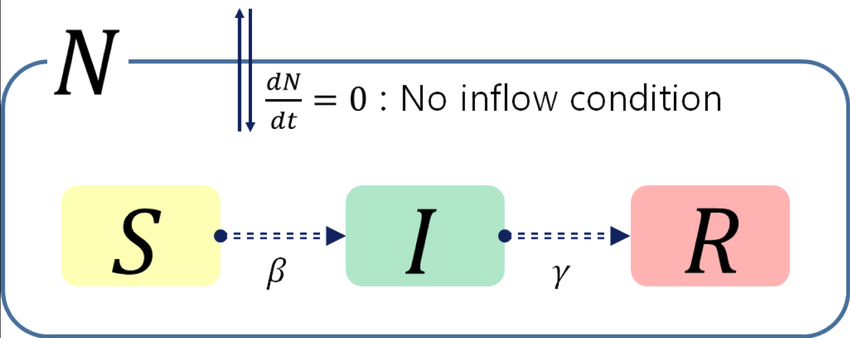

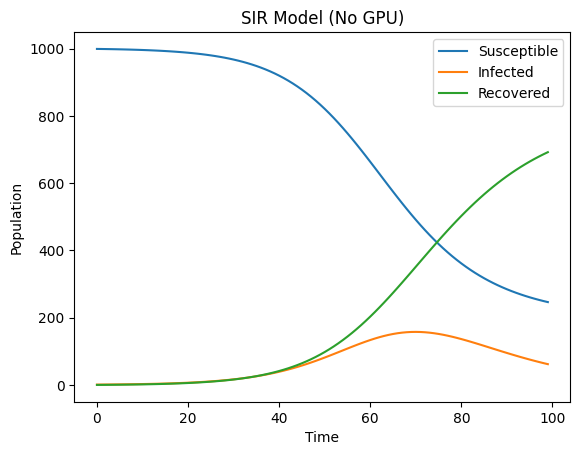

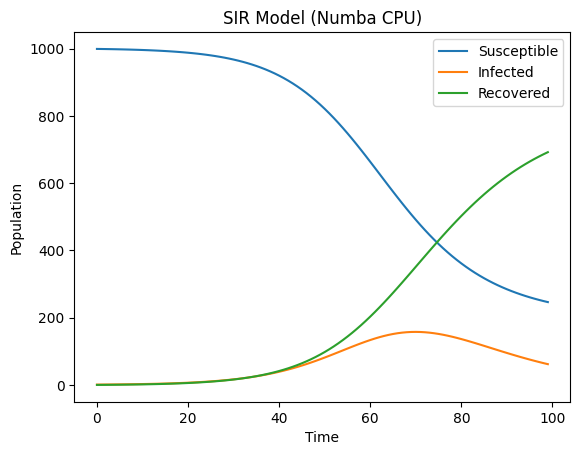

In [ ]:
import numpy as np
from numba import jit, cuda

# SIR model without Numba
def sir_model(S0, I0, R0, beta, gamma, N, t_max):
  S = [S0]
  I = [I0]
  R = [R0]
  for t in range(1, t_max):
    dSdt = -beta * S[-1] * I[-1] / N
    dIdt = beta * S[-1] * I[-1] / N - gamma * I[-1]
    dRdt = gamma * I[-1]
    S.append(S[-1] + dSdt)
    I.append(I[-1] + dIdt)
    R.append(R[-1] + dRdt)
  return np.array(S), np.array(I), np.array(R)

# SIR model with Numba (CPU)
@jit(nopython=True)
def sir_model_numba(S0, I0, R0, beta, gamma, N, t_max):
    S = np.zeros(t_max)
    I = np.zeros(t_max)
    R = np.zeros(t_max)
    S[0] = S0
    I[0] = I0
    R[0] = R0
    for t in range(1, t_max):
        dSdt = -beta * S[t-1] * I[t-1] / N
        dIdt = beta * S[t-1] * I[t-1] / N - gamma * I[t-1]
        dRdt = gamma * I[t-1]
        S[t] = S[t-1] + dSdt
        I[t] = I[t-1] + dIdt
        R[t] = R[t-1] + dRdt
    return S, I, R

# Example usage
S0, I0, R0 = 999, 1, 0
beta, gamma = 0.2, 0.1
N = S0 + I0 + R0
t_max = 100

S, I, R = sir_model(S0, I0, R0, beta, gamma, N, t_max)
Sn, In, Rn = sir_model_numba(S0, I0, R0, beta, gamma, N, t_max)

# You would typically plot S, I, and R here to visualize the results
# Example using matplotlib
import matplotlib.pyplot as plt
plt.plot(S, label="Susceptible")
plt.plot(I, label="Infected")
plt.plot(R, label="Recovered")
plt.legend()
plt.xlabel('Time')
plt.ylabel('Population')
plt.title("SIR Model (No GPU)")
plt.show()

plt.plot(Sn, label="Susceptible")
plt.plot(In, label="Infected")
plt.plot(Rn, label="Recovered")
plt.legend()
plt.xlabel('Time')
plt.ylabel('Population')
plt.title("SIR Model (Numba CPU)")
plt.show()
